# Generic Movement Recognition: Baseline Model

This notebook establishes a baseline movement-recognition model for the Adaptive Embodied AI project.

The purpose of this experiment is to determine whether the extracted
movement representation contains sufficient information to recognise the five instructed movement classes.

Unlike the exploratory analysis notebook, this notebook evaluates model performance quantitatively.

The experiment uses trials as the fundamental unit of analysis rather than individual frames. This prevents frames from the same movement sequence from being treated as independent observations.

The baseline provides a reference point for the subsequent personalisation experiment.

## Experimental Design

The dataset contains:

- 2 participants
- 2 recording sessions per participant
- 5 movement classes
- 5 repetitions of each movement per session
- 100 trials in total

Each trial contains approximately 4 seconds of sequential pose-derived
movement features.

The baseline trains on session 01 and evaluates on session 02 for each participant.

The primary evaluation unit is therefore the trial.

The main evaluation metrics are:

- Balanced Accuracy
- Macro F1
- Confusion Matrix

The evaluation is performed at the trial level to avoid leakage between frames belonging to the same movement sequence.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
)

from adaptive_embodied_ai.representation.normalization import (
    MovementNormalizer,
)

In [2]:
DATA_DIR = Path("../data/movement")

files = sorted(DATA_DIR.glob("P*_session_*.csv"))

if not files:
    raise FileNotFoundError(
        f"No participant/session CSV files found in {DATA_DIR.resolve()}"
    )

frames = []

for file in files:
    frame = pd.read_csv(file)
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(files)} files")
print(f"Dataset shape: {df.shape}")

df.head()

Loaded 4 files
Dataset shape: (12049, 14)


,participant_id,session_id,trial_id,movement_label,timestamp,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
0,P01,session_01,1,neutral,0.000286,0.512240,-0.003828,-0.809468,0.000000,0.000000,0.000000,-1.819797,0.000000,0.000000
1,P01,session_01,1,neutral,0.089765,0.522485,0.001988,-0.821021,0.001142,0.041825,0.467600,-1.964989,-0.080764,1.016539
2,P01,session_01,1,neutral,0.120218,0.526950,-0.002607,-0.825294,0.004594,0.006284,0.255614,-1.953916,-0.004368,0.293103
3,P01,session_01,1,neutral,0.161072,0.528400,-0.000946,-0.826692,0.001198,0.004504,0.114079,-1.970659,-0.041060,1.011501
4,P01,session_01,1,neutral,0.199235,0.528685,-0.000832,-0.819518,-0.000120,0.001390,0.036564,-2.000928,-0.021275,0.558671


## Define Features

The baseline uses the compact movement representation developed during the representation and exploratory-analysis stages.

The feature set combines:

- body geometry;
- head position relative to the torso;
- torso displacement;
- 2D movement magnitude;
- estimated depth-related movement;
- 3D movement magnitude.

The 2D and depth-related features will later support an ablation comparing 2D-only and 2D + depth representations.

In [3]:
feature_columns = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

target_column = "movement_label"

## Construct Trial-Level Dataset

The raw dataset contains frame-level observations, but frames from the same trial are not independent samples.

To avoid leakage and preserve the experimental structure, each trial is converted into a single feature vector.

For each movement feature, we calculate:

- mean value across the trial;
- standard deviation across the trial.

This produces a fixed-length representation for every trial while retaining both the typical movement state and its within-trial variability.

In [4]:
trial_group_columns = [
    "participant_id",
    "session_id",
    "trial_id",
    "movement_label",
]

trial_features = (
    df.groupby(trial_group_columns)[feature_columns]
    .agg(["mean", "std"])
)

trial_features.columns = [
    f"{feature}_{stat}"
    for feature, stat in trial_features.columns
]

trial_features = trial_features.reset_index()

print("Trial-level dataset shape:")
print(trial_features.shape)

display(trial_features.head())

Trial-level dataset shape:
(100, 22)


,participant_id,session_id,trial_id,movement_label,shoulder_width_mean,shoulder_width_std,head_offset_x_mean,head_offset_x_std,head_offset_y_mean,head_offset_y_std,...,torso_dy_mean,torso_dy_std,movement_speed_mean,movement_speed_std,head_offset_z_mean,head_offset_z_std,torso_dz_mean,torso_dz_std,movement_speed_3d_mean,movement_speed_3d_std
0,P01,session_01,1,neutral,0.529612,0.004275,0.019464,0.007183,-0.800970,0.010974,...,0.000503,0.004243,0.054888,0.057974,-1.887248,0.039513,-0.000173,0.043556,0.920003,0.886335
1,P01,session_01,2,neutral,0.517385,0.003605,0.025469,0.023949,-0.832465,0.005037,...,0.000025,0.001914,0.049913,0.043790,-1.904534,0.029462,0.001170,0.037476,0.805533,0.815746
2,P01,session_01,3,neutral,0.507778,0.002349,0.076977,0.014369,-0.805601,0.010728,...,-0.000053,0.002351,0.054791,0.054652,-1.942788,0.037715,-0.002604,0.048366,1.084661,1.067435
3,P01,session_01,4,neutral,0.496608,0.006886,0.077936,0.004737,-0.800612,0.016712,...,0.000148,0.002370,0.050907,0.056781,-1.972181,0.041128,0.001073,0.071869,1.609406,1.408000
4,P01,session_01,5,neutral,0.504510,0.006171,0.077118,0.029800,-0.807151,0.019858,...,0.000269,0.002426,0.066000,0.060745,-1.961203,0.037682,0.000298,0.055174,1.223005,1.119273


In [5]:
print(
    trial_features["movement_label"]
    .value_counts()
    .sort_index()
)

movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64


In [6]:
# Normalise Features

model_features = [
    column
    for column in trial_features.columns
    if column not in trial_group_columns
]

X = trial_features[model_features]
y = trial_features[target_column]

In [7]:
# Define Evaluation Protocol

train_mask = (
    trial_features["session_id"] == "session_01"
)

test_mask = (
    trial_features["session_id"] == "session_02"
)

train_data = trial_features[train_mask].copy()
test_data = trial_features[test_mask].copy()

print("Training trials:", len(train_data))
print("Test trials:", len(test_data))

Training trials: 50
Test trials: 50


In [8]:
X_train = train_data[model_features]
y_train = train_data[target_column]

X_test = test_data[model_features]
y_test = test_data[target_column]

In [9]:
normalizer = MovementNormalizer()

X_train_scaled = normalizer.fit_transform(X_train)

X_test_scaled = normalizer.transform(X_test)

In [14]:
# Generic Baseline Model

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

model.fit(
    X_train_scaled,
    y_train,
)

print(model)

LogisticRegression(max_iter=1000, random_state=42)


In [15]:
y_pred = model.predict(X_test_scaled)

In [16]:
# Evaluation

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred,
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
)

print(f"Balanced Accuracy: {balanced_accuracy:.3f}")
print(f"Macro F1: {macro_f1:.3f}")

Balanced Accuracy: 0.960
Macro F1: 0.960


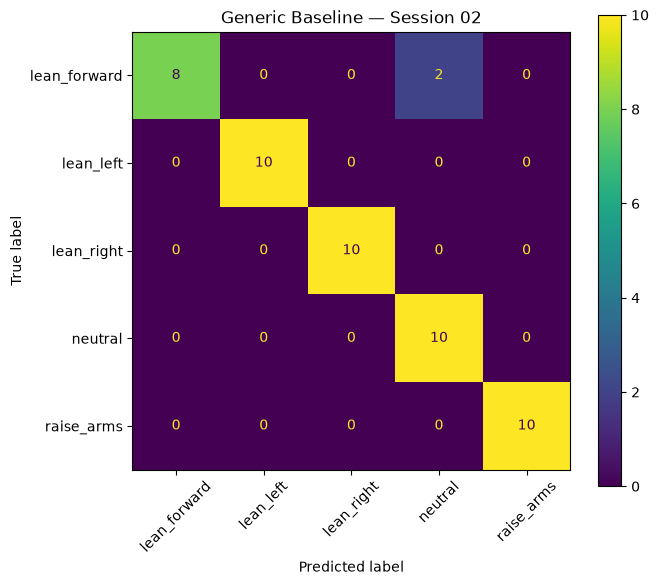

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    xticks_rotation=45,
)

ax.set_title("Generic Baseline — Session 02")
plt.tight_layout()
plt.show()

## Baseline Findings

The generic logistic regression classifier achieves a balanced accuracy of 0.960 and a macro F1 score of 0.960 when trained on session 01 and evaluated on session 02.

This indicates that the current trial-level movement representation contains substantial information for distinguishing the five instructed movement classes across recording sessions.

The high baseline performance also provides an important constraint for the personalisation experiment: any adaptation method must demonstrate improvement over an already strong generic model rather than simply establishing basic movement recognition.